# $\hat p^\star$ for the **distance route** — synthesized non-balanced flat CBM

> **Purpose:** the distance-route mirror of the paper's **Figure 2**
> (`fig:pstar_synth`, from `sec5_empirical/synthesized/nonbalanced_flat_cbm.ipynb`).
> Same two-panel-per-$\eta$ layout, same NMI metric, same $\hat p^\star$ read-off,
> same estimator for $C$ — but the operator is the **centred distance matrix**, not
> the Laplacian.

## What is being measured

Theorem 2 (`thm:main-dist`, `sections/main-result-dist.tex`) recovers the clan split from
the sign pattern of $\mathbf u_1$, the eigenvector of

$$\mathcal B = H\,\mathcal D\,H, \qquad H = I - \tfrac1m\mathbf{11}^\top,
  \qquad \mathcal D_{ij} = -\log S_{ij},\ \ \mathcal D_{ii}=0$$

at the eigenvalue of largest **absolute** value. ($\mathcal B \preceq 0$ for a raw
distance matrix — `lem:split-decomp` — so that is the *most negative* eigenvalue, not the
top algebraic one, whose eigenvector is the degenerate $\mathbf 1$ null direction.)
Theorem 2's rate, `eq:main-rate-dist`, has the same shape as the similarity route's:
$\Theta(\log m/m)$ at fixed $\eta$.

Here $S$ is the closed-form flat CBM ($S_{\rm in}=0.9$ within clan, $S_{\rm out}^{\max}=0.05$
across), so $\mathcal D$ is exact and the reference split is exactly the two true clans —
any loss of agreement at $p<1$ is a pure sub-sampling artifact, with no estimation noise
and no topology-resolution confound.

## Three caveats — read before using these panels

**1. Only $\eta=1$ is inside Theorem 2's certified regime.** Hypotheses (i)–(ii) of
`thm:main-dist` (a positive gap $\Delta\lambda_{\mathcal B}$, and $\mathbf u_1$ piecewise
constant on the two clans) are verified **only** in the balanced flat CBM — that is
`cor:dist-balanced`, and `rem:flat-realization` notes that even that configuration is two
stars, not the binary tree §2 fixes. The $\eta=5,10,15$ panels are *measurements*, not
confirmations: they report what the estimator does at imbalance, in a regime where the
theorem certifies nothing. This is exactly what `DISTANCE_REVIEW.md` §7.2 and F13 warn
about, so it is stated here rather than left for a reader to infer.

**2. Comparability with the paper's two similarity figures is not symmetric.**

| | rounding rule | reps handling | comparable to this notebook? |
|---|---|---|---|
| **Fig 2** (synthesized, similarity) | $\mathrm{sign}(v)$ of the unnormalized Fiedler vector | per-trial NMI | **yes — like-for-like.** Same rule, same per-trial accounting, both closed-form matrices |
| **Fig 3** (generated, similarity) | $k$-means($k$=2) on $L_{\rm sym}$, applied to the **bootstrap-average** of 10 aligned sub-sampled Fiedler vectors | NMI of the averaged vector | **no — layout mirror only** |

Averaged per-rep NMI is not the NMI of the averaged vector, and Fig 3 additionally
short-circuits $p\ge0.9999\to\text{NMI}=1$ and early-stops after two consecutive 100 %
(`src/runners/p_sweep_inner.py:169-185`). Reading a distance curve against Fig 3 as a
head-to-head is the mistake that already got two numbers struck from the manuscript
(`open-items/13-B1.md` [B1/07], `DISTANCE_REVIEW.md` §6.2(8)). Keep the two axes of
[B1/12] apart: *noise tolerance for a fixed split* $\ne$ *which split gets selected*.

**3. Many $\hat p^\star$ read-offs here are censored, not measured.** At $\eta\ge10$ the
distance route never reaches NMI $0.90$ at any $p<1$ for the smaller sizes, so the read-off
is pinned at the grid ceiling ($p=1$, where the "sub-sample" is the full matrix and NMI is
$1$ by construction). Those are non-detections; they are drawn as **open** markers and
excluded from every fitted constant below. The similarity route needed no such handling —
all of its read-offs are sub-threshold — so this is a real asymmetry in the *analysis*, on
top of the protocol asymmetry in point 2. It is also the headline empirical finding of this
notebook: **the distance route degrades sharply with imbalance in a regime where the
similarity route still recovers.**

## Output

Figures are written **outside** `docs/overleafs/v9/figures/` on purpose — see the
`FIG_DIR` cell. Nothing in the manuscript, `paper_figures.py` or `PAPER_MAP.md` is touched
by this notebook.


## Cell 1 — Configuration

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd()
while ROOT.parent != ROOT and not (ROOT / "setup.py").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT / "sub_sampled_fielder_vec"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis.utils.sweep_plots_two_panel import (
    median_ratio_C, plot_pstar_pair_censored, split_censored_pstar,
)
from analysis.utils.sweep_plots import compute_pstar
from analysis.utils.cache import make_full_key, make_subsample_key
from src.cache_io import notebook_dir, sweep_trial
from src.utils.bpart_synth_grid import clan_sizes, collect_griffing_synth_sweeps
from src.utils.griffing import griffing_leading_eigvec
from src.runners.bpart_synthetic import _synthetic_clan_D

# --- grid: copied verbatim from sec5_empirical/synthesized/nonbalanced_flat_cbm.ipynb ---
# so the distance panels and the similarity panels are read against each other.
ETA_VALUES = [1, 5, 10, 15]
S_IN, S_OUT = 0.9, 0.05
# n1 = m/(1+eta) must be exact and 1+eta is 2, 6, 11, 16 -- no single grid divides all
# four, so each eta carries its own list spanning the same ~two decades.
M_GRIDS = {
    1:  [90, 180, 360, 720, 1440, 2880, 5760],    # /2
    5:  [90, 180, 360, 720, 1440, 2880, 5760],    # /6
    10: [88, 176, 352, 704, 1408, 2816, 5632],    # /11
    15: [96, 192, 384, 768, 1536, 3072, 6144],    # /16
}
ms_for = M_GRIDS.__getitem__
M_ALL = sorted({m for ms in M_GRIDS.values() for m in ms})
P_GRID = np.geomspace(1e-4, 1.0, 25)
N_TRIALS = 8
RECOVERY_THRESHOLD = 0.90   # 0.90, not 0.95: at 0.95 the read-off lands on the flat top
#                             of the transition, where one noisy trial moves p-hat-star a
#                             whole grid step.
METRIC = "nmi"
METRIC_LABEL = "NMI"

# ARPACK for the single leading eigenpair. griffing_leading_eigvec's historical path is a
# full O(m^3) eigh to use one column (14.9 s vs 0.12 s at m=6000); "lm_k1" is what makes a
# 25-point grid x 8 trials over this whole grid a ~10-minute job. Verified |cos| = 1 to 10
# decimals and identical sign partitions against the dense path.
EIGSOLVER = "lm_k1"

# Deliberately NOT docs/overleafs/v9/figures/. That tree is validated by
# scripts/sync_paper_figures.py --check, which errors ORPHAN on any PNG there without a
# paper_figures.py entry -- and this notebook produces no paper figure (yet).
# To promote these later: register them in analysis/paper_figures.py, add the
# \includegraphics, then re-point FIG_DIR.
FIG_DIR = notebook_dir("supporting/distance_route")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"eta={ETA_VALUES}  S_in={S_IN}  S_out={S_OUT}")
print(f"|P_GRID|={len(P_GRID)} ({P_GRID[0]:.0e}..{P_GRID[-1]:.0f})  n_trials={N_TRIALS}")
print(f"threshold={RECOVERY_THRESHOLD}  metric={METRIC}  eigsolver={EIGSOLVER}")
print(f"fig_dir={FIG_DIR}")
print()
print("clan sizes (n1, n2) and realized eta:")
for eta in ETA_VALUES:
    parts = []
    for m in ms_for(eta):
        n1, n2 = clan_sizes(m, eta)
        assert n1 * (1 + eta) == m, f"m={m} not divisible by 1+eta={1+eta}"
        parts.append(f"{m}:({n1},{n2})")
    print(f"  eta={eta:>2}: " + "  ".join(parts))

eta=[1, 5, 10, 15]  S_in=0.9  S_out=0.05
|P_GRID|=25 (1e-04..1)  n_trials=8
threshold=0.9  metric=nmi  eigsolver=lm_k1
fig_dir=/Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/notebooks/supporting/distance_route

clan sizes (n1, n2) and realized eta:
  eta= 1: 90:(45,45)  180:(90,90)  360:(180,180)  720:(360,360)  1440:(720,720)  2880:(1440,1440)  5760:(2880,2880)
  eta= 5: 90:(15,75)  180:(30,150)  360:(60,300)  720:(120,600)  1440:(240,1200)  2880:(480,2400)  5760:(960,4800)
  eta=10: 88:(8,80)  176:(16,160)  352:(32,320)  704:(64,640)  1408:(128,1280)  2816:(256,2560)  5632:(512,5120)
  eta=15: 96:(6,90)  192:(12,180)  384:(24,360)  768:(48,720)  1536:(96,1440)  3072:(192,2880)  6144:(384,5760)


## Cell 2 — Sanity: at $p=1$ the sign of $\mathbf u_1$ *is* the true clan split

The distance analogue of the similarity notebook's closed-form Fiedler check. If this
fails, every recovery number below is measured against the wrong reference.

In [2]:
sanity_rows = []
for eta in ETA_VALUES:
    for m in ms_for(eta):
        n1, n2 = clan_sizes(m, eta)
        D = _synthetic_clan_D(n1, n2, S_IN, S_OUT)
        v = griffing_leading_eigvec(D, EIGSOLVER)
        truth = np.r_[np.zeros(n1, bool), np.ones(n2, bool)]
        pred = v >= 0
        # orientation-invariant: the eigenvector's global sign is arbitrary
        acc = max((pred == truth).mean(), (pred != truth).mean())
        sanity_rows.append({"eta": eta, "m": m, "n1": n1, "n2": n2,
                            "clan_recovery_pct": 100.0 * acc})

df_sanity = pd.DataFrame(sanity_rows)
worst = df_sanity["clan_recovery_pct"].min()
print(f"worst exact-clan recovery at p=1 across all {len(df_sanity)} cells: {worst:.2f}%")
assert worst == 100.0, "sign(u1) does not recover the true clans on the full D"
df_sanity.groupby("eta")["clan_recovery_pct"].agg(["min", "max", "count"])

worst exact-clan recovery at p=1 across all 28 cells: 100.00%


,min,max,count
eta,,,
1,100.0,100.0,7
5,100.0,100.0,7
10,100.0,100.0,7
15,100.0,100.0,7


## Cell 3 — Sub-sampling sweep

One call. Every $(\eta, m)$ cell is cached individually under `cache/bpart_sweep/`, so this
is resumable and safely interruptible; a re-run with a smaller `N_TRIALS` reads the first
seeds of the existing cache, keeping old and new comparable.

In [3]:
_counts = {"computed": 0, "cached": 0}

def _on_cell(eta, m, was_cached):
    _counts["cached" if was_cached else "computed"] += 1
    if not was_cached:
        print(f"    COMPUTE eta={eta:>2} m={m:>5}", flush=True)

results_dist = collect_griffing_synth_sweeps(
    M_GRIDS, s_in=S_IN, s_out=S_OUT, p_grid=P_GRID, n_trials=N_TRIALS,
    eigsolver=EIGSOLVER, metric=METRIC, on_cell=_on_cell,
)
print(f"sweep complete: computed={_counts['computed']} cached={_counts['cached']}")

# Shape + endpoint guard: every cell must be (trials x |P_GRID|) and land at NMI 1.0 at p=1.
bad = []
for eta in ETA_VALUES:
    for m in ms_for(eta):
        arr = results_dist[(m, eta)]
        if arr.shape != (N_TRIALS, len(P_GRID)):
            bad.append(f"(m={m}, eta={eta}) shape {arr.shape}")
        elif arr[:, -1].mean() < 0.999:
            bad.append(f"(m={m}, eta={eta}) NMI at p=1 is {arr[:, -1].mean():.4f}")
assert not bad, "sweep output malformed: " + "; ".join(bad)
print(f"all {len(results_dist)} cells are ({N_TRIALS} x {len(P_GRID)}) and reach NMI=1.0 at p=1")

sweep complete: computed=0 cached=28
all 28 cells are (8 x 25) and reach NMI=1.0 at p=1


## Cell 4 — One two-panel figure per $\eta$

Uses `plot_pstar_pair_censored`, which calls the **same** `_draw_recovery_panel` /
`_draw_scale_panel` helpers as the paper's `plot_pstar_pair` — so panel geometry, type
sizes, tick sets, the dashed threshold line and the dotted $C\log m/m$ reference are
identical to Figs 2 and 3, and the $\eta$ appears nowhere in the image.

**The one difference, and why it is needed here.** $\hat p^\star$ is the smallest grid $p$
whose mean NMI clears $0.90$. The largest grid point is $p=1$, where the "sub-sample" *is*
the full matrix and NMI is $1$ by construction — so $\hat p^\star=1$ is always attainable
and means the opposite of a threshold: **the operator never recovered the split below full
data.** On the distance route at $\eta\ge10$ most of the smaller sizes land exactly there.
Those read-offs are right-censored, so they are drawn as **open** markers at the ceiling and
excluded from the fitted reference; filled markers are genuine measurements. Dropping them
invisibly would make the panel look like those sizes were never run.


saved /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/notebooks/supporting/distance_route/pstar_synth_dist_eta1.png


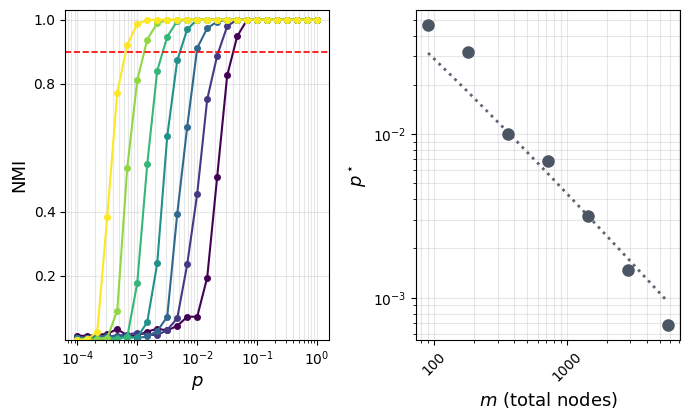

eta= 1: 7 measured, 0 censored at p=1


saved /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/notebooks/supporting/distance_route/pstar_synth_dist_eta5.png


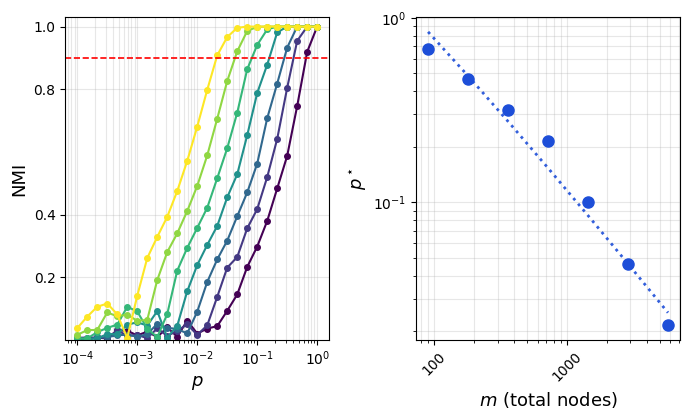

eta= 5: 7 measured, 0 censored at p=1


saved /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/notebooks/supporting/distance_route/pstar_synth_dist_eta10.png


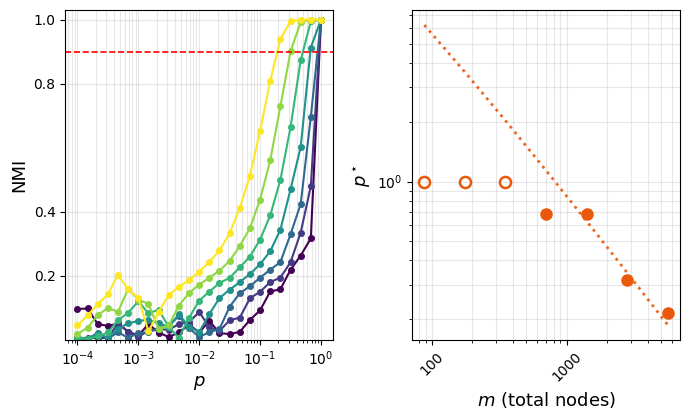

eta=10: 4 measured, 3 censored at p=1  -> m=[88, 176, 352]


saved /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/notebooks/supporting/distance_route/pstar_synth_dist_eta15.png


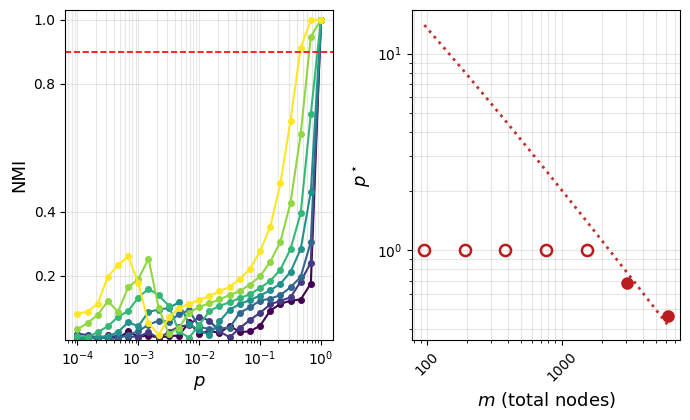

eta=15: 2 measured, 5 censored at p=1  -> m=[96, 192, 384, 768, 1536]


In [4]:
censored_by_eta = {}
for eta in ETA_VALUES:
    _fig, measured, censored = plot_pstar_pair_censored(
        results_dist, P_GRID, eta, ms_for(eta),
        metric_label=METRIC_LABEL, agg="mean", threshold=RECOVERY_THRESHOLD,
        n_ticks=[100, 1000, 10000],            # m spans 88..6144 here, not 500..8000
        size_label=r"$m$ (total nodes)",
        savepath=FIG_DIR / f"pstar_synth_dist_eta{eta}.png",
    )
    censored_by_eta[eta] = [m for m, _ in censored]
    print(f"eta={eta:>2}: {len(measured)} measured, {len(censored)} censored at p=1"
          + (f"  -> m={censored_by_eta[eta]}" if censored else ""))

## Cell 5 — Measured $C$, distance vs similarity

**Diagnostic scaffolding, not a paper metric.** $C$ is the median of the per-point ratios
$\hat p^\star_i / (\log m_i / m_i)$ (`median_ratio_C`) — the estimator the paper's constants
are quoted from, and *not* interchangeable with the least-squares `_theory_ref` used by the
appendix figures. `spread` is $\max_i r_i / \min_i r_i$: how badly one constant fails to
describe the points. When it is large the single $C$ is not a summary, and the table says so
rather than hiding it.

**Censored points are excluded from $C$.** As in the figure cell, $\hat p^\star=1$ is not a
threshold — it is a non-detection (NMI is $1$ at $p=1$ by construction). Fitting through them
manufactures a rate out of failures: at $\eta=15$ five of seven sizes are censored, and
including them gave $C=115.6$ with a $15.5\times$ spread. `n_meas` reports how many genuine
measurements each $C$ rests on; `n_cens` how many sizes never recovered. **A $C$ resting on
fewer than ~3 measured points should not be quoted at all.**

The similarity column is recomputed here **from its own cache** (`cache/sweep_trial`,
complete for all 28 cells — no new compute) through the same `compute_pstar` /
`median_ratio_C` / censoring path, so both columns come from one estimator applied one way.

Two things this table is **not**:
- not a test of `eq:dist-price`'s factor $275$ (`appendix-G.tex:473`). That compares the two
  rates' *parameter groups*, $d_0^2/(d_0-d_1)^2$ against $\beta_0^2/(\rho-\eta\beta_0)^2$,
  not their stated right-hand sides, so a measured ratio neither confirms nor refutes it.
- not a claim that one route beats the other. Per [B1/12], noise tolerance for a fixed split
  and which split gets selected are different axes; only the former is in view here, and at
  $\eta>1$ Theorem 2 certifies nothing at all (see the header).


In [5]:
# Similarity-side per-trial NMI, straight from cache/sweep_trial. Trial keys are rebuilt
# from P_GRID rather than parsed back out of the 4-decimal cache key -- parsing collapses
# the two smallest P_GRID points onto one another.
def load_similarity_results():
    out, missing = {}, 0
    for eta in ETA_VALUES:
        for m in ms_for(eta):
            fk = make_full_key("flat_cbm", eta=eta, n=m, s_in=S_IN, s_out=S_OUT)
            rows = []
            for seed in range(N_TRIALS):
                curve = []
                for p in P_GRID:
                    d = sweep_trial.try_load(fk, make_subsample_key(float(p), seed))
                    val = (d.get("metrics") or {}).get("nmi") if d else None
                    curve.append(np.nan if val is None else float(val))
                rows.append(curve)
            arr = np.asarray(rows, float)
            missing += int(np.isnan(arr).sum())
            out[(m, eta)] = arr
    if missing:
        print(f"  warning: {missing} similarity trials missing from cache (shown as nan)")
    return out

results_sim = load_similarity_results()

pstar_dist = compute_pstar(results_dist, P_GRID, ETA_VALUES, M_ALL,
                           agg="mean", threshold=RECOVERY_THRESHOLD)
pstar_sim = compute_pstar(results_sim, P_GRID, ETA_VALUES, M_ALL,
                          agg="mean", threshold=RECOVERY_THRESHOLD)

rows = []
for eta in ETA_VALUES:
    rec = {"eta": eta}
    for label, pstar in (("dist", pstar_dist), ("sim", pstar_sim)):
        pts = [(m, v) for m, v in pstar.get(eta, []) if m in ms_for(eta)]
        # Drop read-offs pinned at p=1: non-detections, not thresholds.
        measured, censored = split_censored_pstar(pts, P_GRID)
        rec[f"n_meas_{label}"] = f"{len(measured)}/{len(ms_for(eta))}"
        rec[f"n_cens_{label}"] = len(censored)
        if len(measured) >= 2:
            xs = np.array([m for m, _ in measured], float)
            ys = np.array([v for _, v in measured], float)
            C, spread = median_ratio_C(xs, ys)
            rec[f"C_{label}"] = round(C, 3)
            rec[f"spread_{label}"] = round(spread, 1)
        else:
            rec[f"C_{label}"] = np.nan
            rec[f"spread_{label}"] = np.nan
    if np.isfinite(rec["C_dist"]) and np.isfinite(rec["C_sim"]) and rec["C_sim"]:
        rec["C_dist/C_sim"] = round(rec["C_dist"] / rec["C_sim"], 2)
    else:
        rec["C_dist/C_sim"] = np.nan
    rows.append(rec)

df_C = pd.DataFrame(rows)[
    ["eta", "C_dist", "spread_dist", "n_meas_dist", "n_cens_dist",
     "C_sim", "spread_sim", "n_meas_sim", "n_cens_sim", "C_dist/C_sim"]
]
print("p* = C log m / m,  C = median of per-point ratios over MEASURED points only")
print("      (DIAGNOSTIC -- not a paper metric)")
print("n_meas = sizes with a genuine sub-threshold read-off; n_cens = sizes pinned at p=1")
print("         (i.e. never recovered below full data -- excluded from C)")
print("Quote no C resting on fewer than ~3 measured points.\n")
df_C

p* = C log m / m,  C = median of per-point ratios over MEASURED points only
      (DIAGNOSTIC -- not a paper metric)
n_meas = sizes with a genuine sub-threshold read-off; n_cens = sizes pinned at p=1
         (i.e. never recovered below full data -- excluded from C)
Quote no C resting on fewer than ~3 measured points.



,eta,C_dist,spread_dist,n_meas_dist,n_cens_dist,C_sim,spread_sim,n_meas_sim,n_cens_sim,C_dist/C_sim
0,1,0.626,2.4,7/7,0,3.088,1.7,7/7,0,0.20
1,5,16.782,1.7,7/7,0,7.456,2.1,7/7,0,2.25
2,10,122.211,1.9,4/7,3,12.933,1.8,7/7,0,9.45
3,15,293.778,1.3,2/7,5,15.174,1.8,7/7,0,19.36


In [6]:
# The p-hat-star read-offs behind the table. "1.0" is the grid ceiling = never recovered
# below full data; those are the censored points excluded from C above.
detail = []
for eta in ETA_VALUES:
    d = dict(pstar_dist.get(eta, []))
    s = dict(pstar_sim.get(eta, []))
    for m in ms_for(eta):
        detail.append({"eta": eta, "m": m,
                       "pstar_dist": d.get(m, np.nan), "pstar_sim": s.get(m, np.nan)})
df_detail = pd.DataFrame(detail)
print("censored (p*=1, never recovered below full data):")
for eta in ETA_VALUES:
    cens = sorted(censored_by_eta.get(eta, []))
    print(f"  eta={eta:>2}: dist m={cens if cens else '-'}")
_, cens_sim_all = split_censored_pstar(
    [(m, v) for eta in ETA_VALUES for m, v in pstar_sim.get(eta, [])], P_GRID)
print(f"  similarity route: {len(cens_sim_all)} censored cells across all eta")
df_detail.pivot(index="m", columns="eta", values=["pstar_dist", "pstar_sim"]).round(5)

censored (p*=1, never recovered below full data):
  eta= 1: dist m=-
  eta= 5: dist m=-
  eta=10: dist m=[88, 176, 352]
  eta=15: dist m=[96, 192, 384, 768, 1536]
  similarity route: 0 censored cells across all eta


pstar_dist                            pstar_sim                    \
eta          1        5        10       15        1        5        10   
m                                                                        
88          NaN      NaN  1.00000      NaN       NaN      NaN  0.68129   
90      0.04642  0.68129      NaN      NaN   0.21544  0.21544      NaN   
96          NaN      NaN      NaN  1.00000       NaN      NaN      NaN   
176         NaN      NaN  1.00000      NaN       NaN      NaN  0.46416   
180     0.03162  0.46416      NaN      NaN   0.10000  0.21544      NaN   
192         NaN      NaN      NaN  1.00000       NaN      NaN      NaN   
352         NaN      NaN  1.00000      NaN       NaN      NaN  0.21544   
360     0.01000  0.31623      NaN      NaN   0.04642  0.14678      NaN   
384         NaN      NaN      NaN  1.00000       NaN      NaN      NaN   
704         NaN      NaN  0.68129      NaN       NaN      NaN  0.10000   
720     0.00681  0.21544      NaN      NaN   0.03162  0.06813      NaN   
768         NaN      NaN      NaN  1.00000       NaN      NaN      NaN   
1408        NaN      NaN  0.68129      NaN       NaN      NaN  0.04642   
1440    0.00316  0.10000      NaN      NaN   0.01468  0.04642      NaN   
1536        NaN      NaN      NaN  1.00000       NaN      NaN      NaN   
2816        NaN      NaN  0.31623      NaN       NaN      NaN  0.03162   
2880    0.00147  0.04642      NaN      NaN   0.00681  0.01468      NaN   
3072        NaN      NaN      NaN  0.68129       NaN      NaN      NaN   
5632        NaN      NaN  0.21544      NaN       NaN      NaN  0.02154   
5760    0.00068  0.02154      NaN      NaN   0.00464  0.01000      NaN   
6144        NaN      NaN      NaN  0.46416       NaN      NaN      NaN   

               
eta        15  
m              
88        NaN  
90        NaN  
96    0.68129  
176       NaN  
180       NaN  
192   0.46416  
352       NaN  
360       NaN  
384   0.31623  
704       NaN  
720       NaN  
768   0.10000  
1408      NaN  
1440      NaN  
1536  0.06813  
2816      NaN  
2880      NaN  
3072  0.04642  
5632      NaN  
5760      NaN  
6144  0.02154